In [20]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from StockPickingModel import StockPickingModel

## Funciones auxiliares

In [21]:
# 1. RSI (Relative Strength Index)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# 2. MACD (Moving Average Convergence Divergence)
def calculate_macd(series):
    exp1 = series.ewm(span=12, adjust=False).mean()
    exp2 = series.ewm(span=26, adjust=False).mean()
    return exp1 - exp2

In [22]:
# 1. Definimos la lista de los 30 tickers del Dow Jones
# Estos son los símbolos actuales de las 30 empresas más grandes de EE.UU.
tickers = [
    "AAPL", "MSFT", "AMZN", "GS", "UNH", "V", "HD", "CRM", "CAT", "MA",
    "JNJ", "PG", "WMT", "JPM", "AXP", "CVX", "DIS", "BA", "MCD", "MMM",
    "INTC", "TRV", "IBM", "MRK", "NKE", "VZ", "HON", "CSCO", "AMGN", "KO"
]

# 2. Descargamos los datos
# El paper usa un rango largo. Vamos a pedir 5 años para tener suficiente para entrenar.
# '1d' es diario, luego lo convertiremos a semanal.
print("Descargando datos...")
data = yf.download(tickers, start="2019-01-01", end="2024-01-01", interval="1d")

# 3. Extraemos solo el precio de Cierre (Close) y el Volumen
# El paper enfatiza usar 'Close' para que la estrategia sea ejecutable.
precios_close = data['Close']
volumen = data['Volume']

# 4. Convertir a datos SEMANALES (como pide el paper)
# Usamos 'W-WED' para obtener el precio del miércoles de cada semana
precios_semanales = precios_close.resample('W-WED').first()

# 5. Formatear para Machine Learning (Stacking)
# Queremos una tabla donde cada fila sea (Fecha, Ticker, Precio)
df_final = precios_semanales.stack().reset_index()
df_final.columns = ['Fecha', 'Ticker', 'Precio_Close']

[*****                 10%                       ]  3 of 30 completed

Descargando datos...


[*********************100%***********************]  30 of 30 completed


In [23]:
# Aseguramos que los datos estén ordenados por ticker y fecha
df_final = df_final.sort_values(by=['Ticker', 'Fecha'])

# --- PASO 1: Features Técnicas ---
# Retorno semanal (Momentum corto)
df_final['Retorno_1W'] = df_final.groupby('Ticker')['Precio_Close'].pct_change(1)

# Momentum de 4 semanas (1 mes aprox)
df_final['Momentum_4W'] = df_final.groupby('Ticker')['Precio_Close'].pct_change(4)

# Volatilidad (Desviación estándar de los últimos 4 retornos)
df_final['Volatilidad_4W'] = df_final.groupby('Ticker')['Retorno_1W'].transform(lambda x: x.rolling(4).std())

# Relación con Media Móvil de 20 semanas
df_final['SMA_20'] = df_final.groupby('Ticker')['Precio_Close'].transform(lambda x: x.rolling(20).mean())
df_final['Distancia_SMA'] = df_final['Precio_Close'] / df_final['SMA_20']

# RSI y MACD
df_final['RSI'] = df_final.groupby('Ticker')['Precio_Close'].transform(lambda x: calculate_rsi(x))
df_final['MACD'] = df_final.groupby('Ticker')['Precio_Close'].transform(lambda x: calculate_macd(x))

df_final.head()

,Fecha,Ticker,Precio_Close,Retorno_1W,Momentum_4W,Volatilidad_4W,SMA_20,Distancia_SMA,RSI,MACD
0,2019-01-02,AAPL,37.503727,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
30,2019-01-09,AAPL,33.768078,-0.099607,NaN,NaN,NaN,NaN,NaN,-0.298000
60,2019-01-16,AAPL,36.525284,0.081651,NaN,NaN,NaN,NaN,NaN,-0.308133
90,2019-01-23,AAPL,37.014503,0.013394,NaN,NaN,NaN,NaN,NaN,-0.273533
120,2019-01-30,AAPL,36.264050,-0.020275,-0.033055,0.075332,NaN,NaN,NaN,-0.303174


In [24]:
# --- PASO 2: El Target (La clave del paper) ---
# 1. Calculamos el retorno de la SEMANA SIGUIENTE (shift -1)
df_final['Retorno_Next_Week'] = df_final.groupby('Ticker')['Retorno_1W'].shift(-1)

# 2. Ranking cross-sectional por semana (mayor retorno = mejor rank)
df_final['Rank_Semanal'] = df_final.groupby('Fecha')['Retorno_Next_Week'].rank(method='first', ascending=False)

# 3. Target binario: 1 si está dentro del Top N de su semana, 0 si no
TOP_N = 5
df_final['Target'] = (df_final['Rank_Semanal'] <= TOP_N).astype(int)

# Limpiamos filas con valores vacíos (las primeras semanas no tienen indicadores y la última no tiene target)
df_ml = df_final.dropna()

In [25]:
# 1. Separar variables (X) del objetivo (y)
features = df_ml.columns.difference(['Fecha', 'Ticker', 'Target', 'Retorno_Next_Week', 'Rank_Semanal'])
X = df_ml[features]
y = df_ml['Target']

# 2. Split Temporal
# Usamos una fecha de corte (por ejemplo, inicio de 2023)
split_date = '2023-01-01'
train_idx = df_ml['Fecha'] < split_date
test_idx = df_ml['Fecha'] >= split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 3. Crear e Instanciar el modelo de Ensemble (Random Forest)
# Usamos 100 árboles para empezar
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=42, 
    class_weight={0: 1, 1: 5} # Le damos 5 veces más importancia a la clase 1
)

# 4. Entrenar
model.fit(X_train, y_train)

# 5. Predecir
y_pred = model.predict(X_test)

# 6. Evaluar
print(f"Accuracy en Test: {accuracy_score(y_test, y_pred):.2%}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

Accuracy en Test: 68.97%

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.77      0.81      1300
           1       0.19      0.27      0.22       260

    accuracy                           0.69      1560
   macro avg       0.52      0.52      0.51      1560
weighted avg       0.73      0.69      0.71      1560



In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA ESTRATEGIA CON BUFFER ---
n_activos_objetivo = 5    # Queremos tener siempre 5 acciones
umbral_salida = 8         # Una acción solo se vende si cae por debajo del puesto 8
coste_operacion = 0.001   # 0.1% de comisión por cada movimiento
capital_inicial = 10000 

# Asegúrate de tener las probabilidades (Scores) actualizadas
df_test = df_ml[test_idx].copy()
df_test['Score'] = model.predict_proba(X_test[features])[:, 1]

fechas = sorted(df_test['Fecha'].unique())
cartera_actual = set()
historial_neto = []

print(f"Iniciando backtesting con Buffer (N={n_activos_objetivo}, Buffer={umbral_salida})...")

for i in range(len(fechas) - 1):
    fecha_hoy = fechas[i]
    
    # 1. Obtener ranking de la semana actual ordenado por Score
    datos_hoy = df_test[df_test['Fecha'] == fecha_hoy].sort_values('Score', ascending=False)
    
    if i == 0:
        # La primera semana compramos simplemente las Top N
        top_n_hoy = datos_hoy.head(n_activos_objetivo)
        nuevos_elegidos = set(top_n_hoy['Ticker'].tolist())
        num_operaciones = n_activos_objetivo
    else:
        # LÓGICA DE BUFFER:
        # A. Candidatos aceptables para MANTENER (los que están en el Top umbral_salida)
        top_mantenimiento = set(datos_hoy.head(umbral_salida)['Ticker'].tolist())
        
        # B. Identificar cuáles de las que ya tengo siguen siendo aceptables
        quedan_en_cartera = cartera_actual.intersection(top_mantenimiento)
        
        # C. ¿Cuántos huecos nos quedan por rellenar?
        huecos_libres = n_activos_objetivo - len(quedan_en_cartera)
        
        # D. Rellenar huecos con las mejores del ranking que NO estaban ya en cartera
        candidatos_nuevos = [t for t in datos_hoy['Ticker'].tolist() if t not in quedan_en_cartera]
        nuevos_elegidos = set(list(quedan_en_cartera) + candidatos_nuevos[:huecos_libres])
        
        # E. Calcular operaciones (Ventas de las que salieron + Compras de las nuevas)
        a_vender = cartera_actual - nuevos_elegidos
        a_comprar = nuevos_elegidos - cartera_actual
        num_operaciones = len(a_vender) + len(a_comprar)

    # 2. Cálculo de Costes e Ingresos
    # El coste se aplica sobre el peso de cada acción (1/n)
    coste_total = (num_operaciones / n_activos_objetivo) * coste_operacion
    
    # Calculamos el retorno promedio de los 'nuevos_elegidos'
    # Buscamos su retorno real en la columna 'Retorno_Next_Week'
    retorno_promedio_semanal = datos_hoy[datos_hoy['Ticker'].isin(nuevos_elegidos)]['Retorno_Next_Week'].mean()
    
    # Retorno neto final de la semana
    retorno_final = retorno_promedio_semanal - coste_total
    historial_neto.append(retorno_final)
    
    # 3. Actualizar cartera para la próxima semana
    cartera_actual = nuevos_elegidos

# --- RESULTADOS FINALES ---
curva_estrategia = np.cumprod(1 + np.array(historial_neto))
rendimiento_total = (curva_estrategia[-1] - 1) * 100

print(f"Resultado final con Buffer: {rendimiento_total:.2f}%")

Iniciando backtesting con Buffer (N=5, Buffer=8)...
Resultado final con Buffer: 24.07%


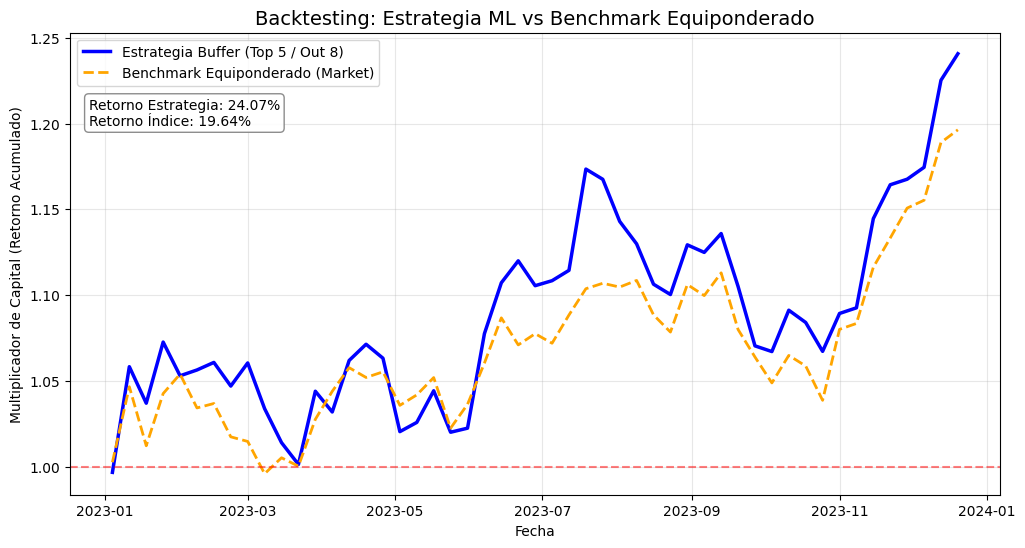

In [27]:
# --- 1. CALCULAR RENDIMIENTO DEL ÍNDICE EQUIPONDERADO ---
# Simulamos comprar todas las acciones del universo (Dow Jones) a partes iguales cada semana
retorno_indice_semanal = []
for fecha in fechas[:-1]:
    # Promedio de rentabilidad de todos los tickers disponibles en esa fecha
    retorno_medio = df_test[df_test['Fecha'] == fecha]['Retorno_Next_Week'].mean()
    retorno_indice_semanal.append(retorno_medio)

curva_indice = np.cumprod(1 + np.array(retorno_indice_semanal))

# --- 2. GRAFICAR ---
plt.figure(figsize=(12,6))

# Línea de tu Estrategia con ML y Buffer
plt.plot(fechas[:-1], curva_estrategia, 
         label=f'Estrategia Buffer (Top {n_activos_objetivo} / Out {umbral_salida})', 
         color='blue', lw=2.5)

# Línea del Índice Equiponderado (Benchmark)
plt.plot(fechas[:-1], curva_indice, 
         label='Benchmark Equiponderado (Market)', 
         color='orange', linestyle='--', lw=2)

# Referencias visuales
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)
plt.title('Backtesting: Estrategia ML vs Benchmark Equiponderado', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Multiplicador de Capital (Retorno Acumulado)')

# Cuadro de texto con resultados finales
rendimiento_indice = (curva_indice[-1] - 1) * 100
texto_resumen = f'Retorno Estrategia: {rendimiento_total:.2f}%\nRetorno Índice: {rendimiento_indice:.2f}%'
plt.annotate(texto_resumen, xy=(0.02, 0.8), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

plt.legend()
plt.grid(alpha=0.3)
plt.show()

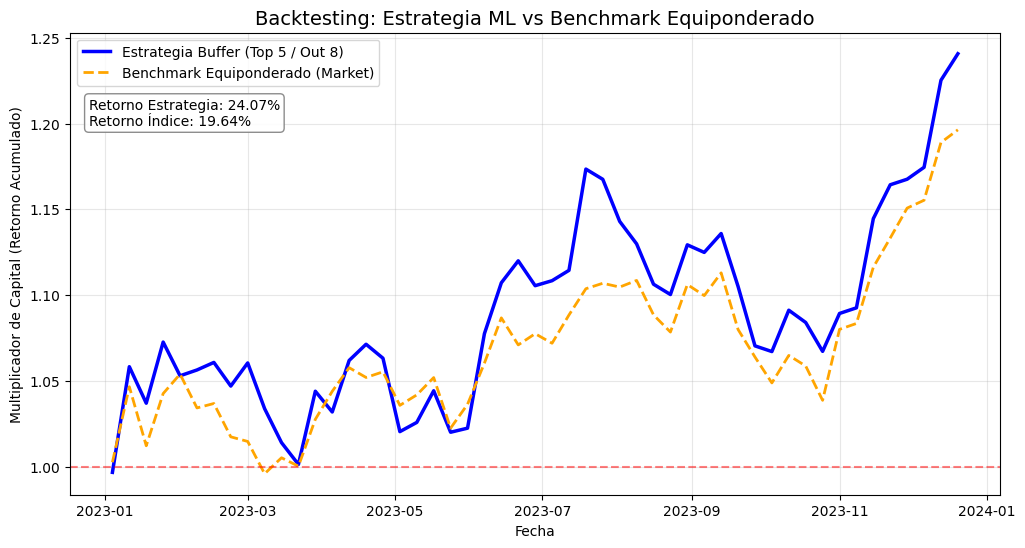

In [28]:
# --- 1. CALCULAR RENDIMIENTO DEL ÍNDICE EQUIPONDERADO ---
# Simulamos comprar todas las acciones del universo (Dow Jones) a partes iguales cada semana
retorno_indice_semanal = []
for fecha in fechas[:-1]:
    # Promedio de rentabilidad de todos los tickers disponibles en esa fecha
    retorno_medio = df_test[df_test['Fecha'] == fecha]['Retorno_Next_Week'].mean()
    retorno_indice_semanal.append(retorno_medio)

curva_indice = np.cumprod(1 + np.array(retorno_indice_semanal))

# --- 2. GRAFICAR ---
plt.figure(figsize=(12,6))

# Línea de tu Estrategia con ML y Buffer
plt.plot(fechas[:-1], curva_estrategia, 
         label=f'Estrategia Buffer (Top {n_activos_objetivo} / Out {umbral_salida})', 
         color='blue', lw=2.5)

# Línea del Índice Equiponderado (Benchmark)
plt.plot(fechas[:-1], curva_indice, 
         label='Benchmark Equiponderado (Market)', 
         color='orange', linestyle='--', lw=2)

# Referencias visuales
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)
plt.title('Backtesting: Estrategia ML vs Benchmark Equiponderado', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Multiplicador de Capital (Retorno Acumulado)')

# Cuadro de texto con resultados finales
rendimiento_indice = (curva_indice[-1] - 1) * 100
texto_resumen = f'Retorno Estrategia: {rendimiento_total:.2f}%\nRetorno Índice: {rendimiento_indice:.2f}%'
plt.annotate(texto_resumen, xy=(0.02, 0.8), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

plt.legend()
plt.grid(alpha=0.3)
plt.show()

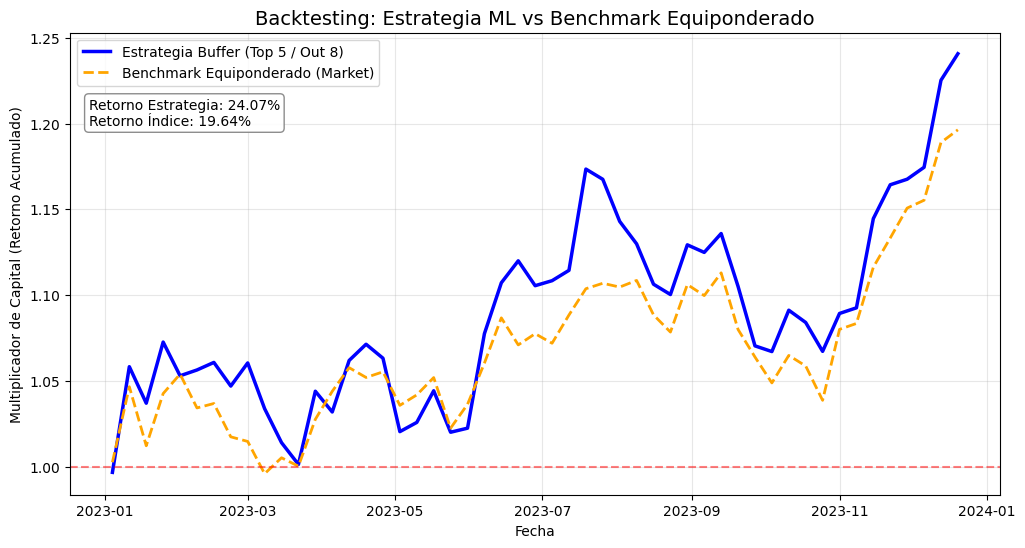

In [29]:
# --- 1. CALCULAR RENDIMIENTO DEL ÍNDICE EQUIPONDERADO ---
# Simulamos comprar todas las acciones del universo (Dow Jones) a partes iguales cada semana
retorno_indice_semanal = []
for fecha in fechas[:-1]:
    # Promedio de rentabilidad de todos los tickers disponibles en esa fecha
    retorno_medio = df_test[df_test['Fecha'] == fecha]['Retorno_Next_Week'].mean()
    retorno_indice_semanal.append(retorno_medio)

curva_indice = np.cumprod(1 + np.array(retorno_indice_semanal))

# --- 2. GRAFICAR ---
plt.figure(figsize=(12,6))

# Línea de tu Estrategia con ML y Buffer
plt.plot(fechas[:-1], curva_estrategia, 
         label=f'Estrategia Buffer (Top {n_activos_objetivo} / Out {umbral_salida})', 
         color='blue', lw=2.5)

# Línea del Índice Equiponderado (Benchmark)
plt.plot(fechas[:-1], curva_indice, 
         label='Benchmark Equiponderado (Market)', 
         color='orange', linestyle='--', lw=2)

# Referencias visuales
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)
plt.title('Backtesting: Estrategia ML vs Benchmark Equiponderado', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Multiplicador de Capital (Retorno Acumulado)')

# Cuadro de texto con resultados finales
rendimiento_indice = (curva_indice[-1] - 1) * 100
texto_resumen = f'Retorno Estrategia: {rendimiento_total:.2f}%\nRetorno Índice: {rendimiento_indice:.2f}%'
plt.annotate(texto_resumen, xy=(0.02, 0.8), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

plt.legend()
plt.grid(alpha=0.3)
plt.show()